In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

In [2]:
df_train = pd.read_csv('test.csv')
df_test = pd.read_csv('test.csv')


In [3]:
df_train

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,555714,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,Michael,Olson,M,558 Michael Estates,...,40.4931,-91.8912,519,Town planner,1966-02-13,9b1f753c79894c9f4b71f04581835ada,1388534347,39.946837,-91.333331,0
555715,555715,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,Jose,Vasquez,M,572 Davis Mountains,...,29.0393,-95.4401,28739,Futures trader,1999-12-27,2090647dac2c89a1d86c514c427f5b91,1388534349,29.661049,-96.186633,0
555716,555716,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,Ann,Lawson,F,144 Evans Islands Apt. 683,...,46.1966,-118.9017,3684,Musician,1981-11-29,6c5b7c8add471975aa0fec023b2e8408,1388534355,46.658340,-119.715054,0
555717,555717,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,Eric,Preston,M,7020 Doyle Stream Apt. 951,...,44.6255,-116.4493,129,Cartographer,1965-12-15,14392d723bb7737606b2700ac791b7aa,1388534364,44.470525,-117.080888,0


In [4]:
df_train.drop(df_train.columns[0], axis=1, inplace=True)
df_test.drop(df_test.columns[0], axis=1, inplace=True)

In [5]:
df_train

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,Michael,Olson,M,558 Michael Estates,Luray,...,40.4931,-91.8912,519,Town planner,1966-02-13,9b1f753c79894c9f4b71f04581835ada,1388534347,39.946837,-91.333331,0
555715,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,Jose,Vasquez,M,572 Davis Mountains,Lake Jackson,...,29.0393,-95.4401,28739,Futures trader,1999-12-27,2090647dac2c89a1d86c514c427f5b91,1388534349,29.661049,-96.186633,0
555716,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,Ann,Lawson,F,144 Evans Islands Apt. 683,Burbank,...,46.1966,-118.9017,3684,Musician,1981-11-29,6c5b7c8add471975aa0fec023b2e8408,1388534355,46.658340,-119.715054,0
555717,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,Eric,Preston,M,7020 Doyle Stream Apt. 951,Mesa,...,44.6255,-116.4493,129,Cartographer,1965-12-15,14392d723bb7737606b2700ac791b7aa,1388534364,44.470525,-117.080888,0


In [6]:
#data types
print(df_train.dtypes)

trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object


In [7]:
print(df_train.isnull().sum())
print(df_test.isnull().sum())

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop       

In [8]:
print(df_train.shape)
print(f"Duplicate rows: {df_train.duplicated().sum()}")

print(df_test.shape)
print(f"Duplicate rows: {df_test.duplicated().sum()}")

(555719, 22)
Duplicate rows: 0
(555719, 22)
Duplicate rows: 0


In [9]:
#check for class imbalance
print(df_train['is_fraud'].value_counts())
print(df_train['is_fraud'].value_counts(normalize=True) * 100)

is_fraud
0    553574
1      2145
Name: count, dtype: int64
is_fraud
0    99.614014
1     0.385986
Name: proportion, dtype: float64


In [12]:
#some light feature eng
df_train['trans_date_trans_time'] = pd.to_datetime(df_train['trans_date_trans_time'])
df_train['dob'] = pd.to_datetime(df_train['dob'])

df_train['trans_hour'] = df_train['trans_date_trans_time'].dt.hour
df_train['trans_dayofweek'] = df_train['trans_date_trans_time'].dt.dayofweek
df_train['trans_month'] = df_train['trans_date_trans_time'].dt.month
df_train['age'] = (df_train['trans_date_trans_time'] - df_train['dob']).dt.days // 365

print(df_train[['trans_hour', 'trans_dayofweek', 'trans_month', 'age']].head())

#have to do it for test too
df_test['trans_date_trans_time'] = pd.to_datetime(df_test['trans_date_trans_time'])
df_test['dob'] = pd.to_datetime(df_test['dob'])

df_test['trans_hour'] = df_test['trans_date_trans_time'].dt.hour
df_test['trans_dayofweek'] = df_test['trans_date_trans_time'].dt.dayofweek
df_test['trans_month'] = df_test['trans_date_trans_time'].dt.month
df_test['age'] = (df_test['trans_date_trans_time'] - df_test['dob']).dt.days // 365

print(df_test[['trans_hour', 'trans_dayofweek', 'trans_month', 'age']].head())

   trans_hour  trans_dayofweek  trans_month  age
0          12                6            6   52
1          12                6            6   30
2          12                6            6   49
3          12                6            6   32
4          12                6            6   65
   trans_hour  trans_dayofweek  trans_month  age
0          12                6            6   52
1          12                6            6   30
2          12                6            6   49
3          12                6            6   32
4          12                6            6   65


In [11]:
df_train

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,trans_hour,trans_dayofweek,trans_month,age
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,...,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0,12,6,6,52
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,...,1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0,12,6,6,30
2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,...,1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0,12,6,6,49
3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,...,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0,12,6,6,32
4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,...,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0,12,6,6,65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,Michael,Olson,M,558 Michael Estates,Luray,...,1966-02-13,9b1f753c79894c9f4b71f04581835ada,1388534347,39.946837,-91.333331,0,23,3,12,54
555715,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,Jose,Vasquez,M,572 Davis Mountains,Lake Jackson,...,1999-12-27,2090647dac2c89a1d86c514c427f5b91,1388534349,29.661049,-96.186633,0,23,3,12,21
555716,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,Ann,Lawson,F,144 Evans Islands Apt. 683,Burbank,...,1981-11-29,6c5b7c8add471975aa0fec023b2e8408,1388534355,46.658340,-119.715054,0,23,3,12,39
555717,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,Eric,Preston,M,7020 Doyle Stream Apt. 951,Mesa,...,1965-12-15,14392d723bb7737606b2700ac791b7aa,1388534364,44.470525,-117.080888,0,23,3,12,55


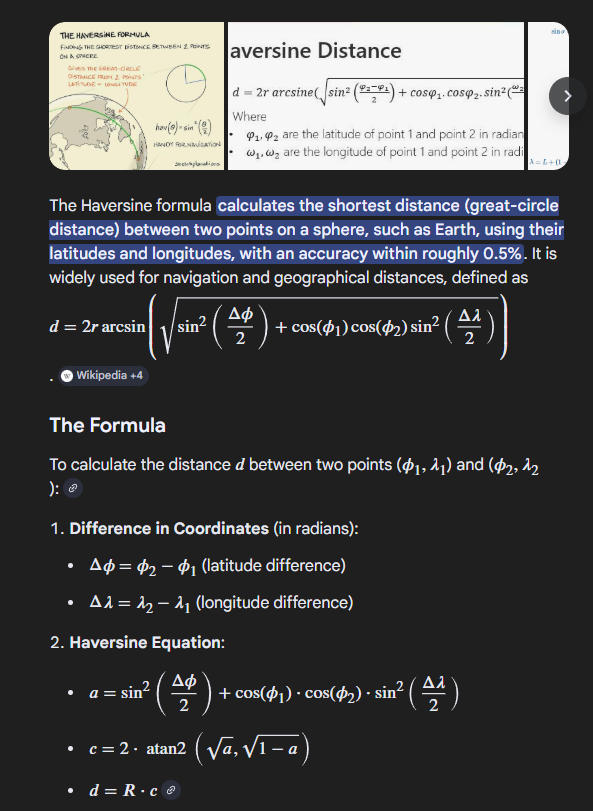

In [ ]:
#more feature engineering
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a)) #guys rememer that atan can be written using arcsin

df_train['distance_km'] = haversine_distance(
    df_train['lat'], df_train['long'], df_train['merch_lat'], df_train['merch_long']
)

df_test['distance_km'] = haversine_distance(
    df_test['lat'], df_test['long'], df_test['merch_lat'], df_test['merch_long']
)

print(df_train.groupby('is_fraud')['distance_km'].mean())
#rough this means that distance is not a strong signal for it which I was hoping that it would be.

is_fraud
0    76.104480
1    76.213905
Name: distance_km, dtype: float64


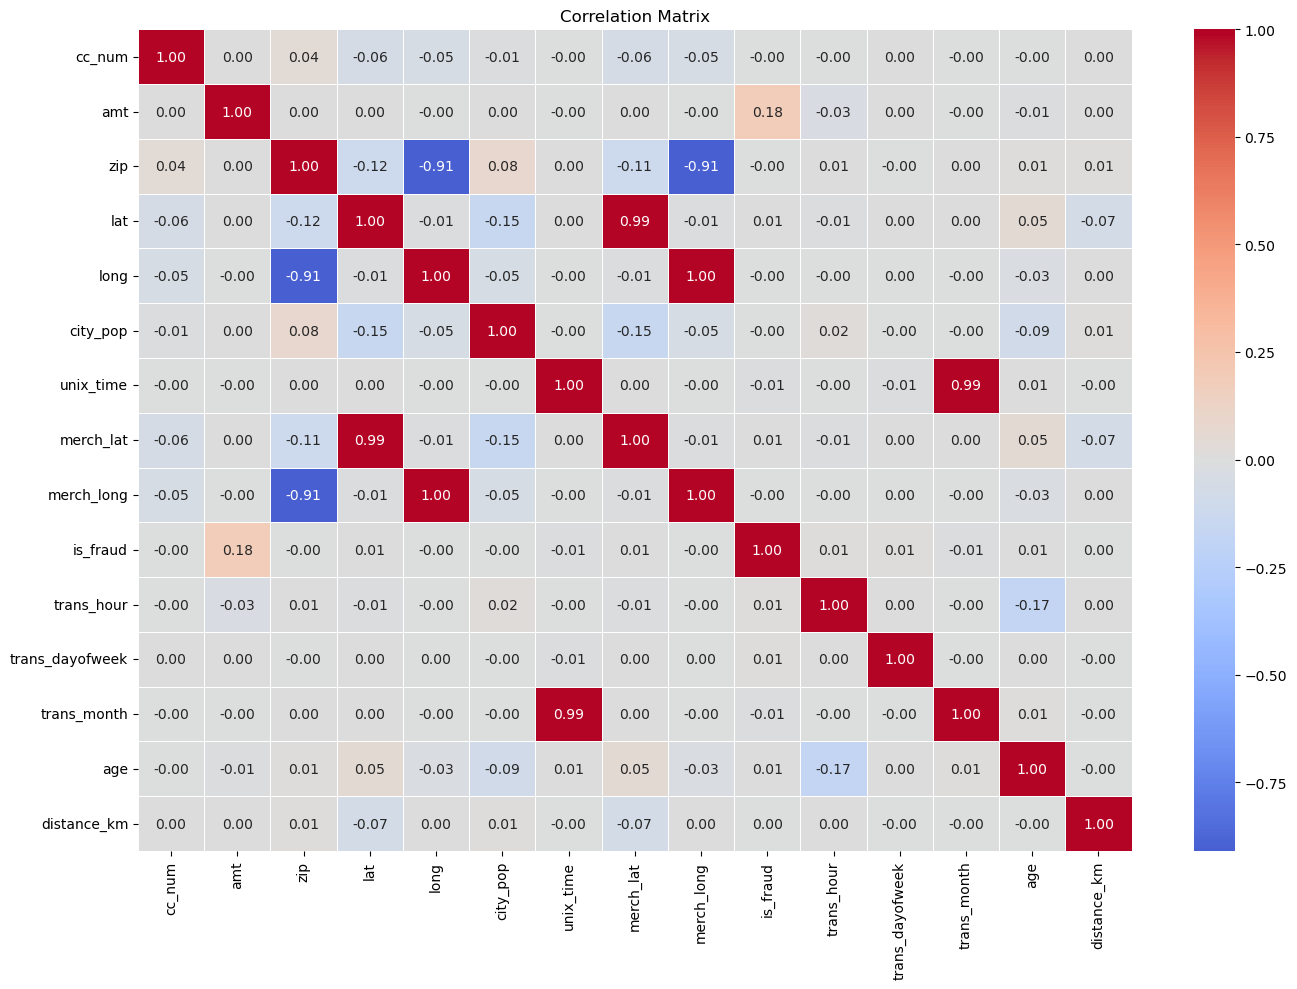

In [15]:
numeric_cols = df_train.select_dtypes(include=np.number).columns.tolist()

corr = df_train[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

bunch of multicolinear stuff so we gonna drop those and some of them have different ways of encoding stuff so those really have no meaning so I shall be dropping those too

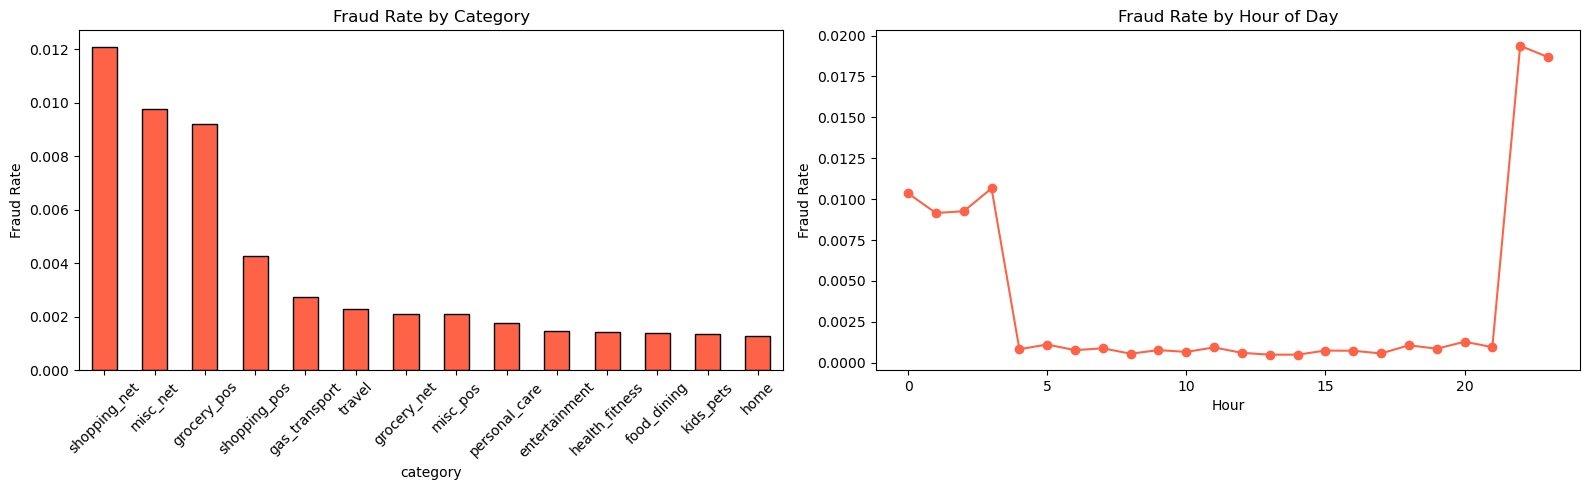

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_train.groupby('category')['is_fraud'].mean().sort_values(ascending=False).plot.bar(
    ax=axes[0], color='tomato', edgecolor='black')
axes[0].set_title('Fraud Rate by Category')
axes[0].set_ylabel('Fraud Rate')
axes[0].tick_params(axis='x', rotation=45)

df_train.groupby('trans_hour')['is_fraud'].mean().plot(
    ax=axes[1], marker='o', color='tomato')
axes[1].set_title('Fraud Rate by Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Fraud Rate')

plt.tight_layout()
plt.show()

damn the scammers really working overtime at night

In [17]:
print(f"Unique cities: {df_train['city'].nunique()}")
print(f"Unique states: {df_train['state'].nunique()}")

Unique cities: 849
Unique states: 50


In [18]:
cols_to_drop = [
    'cc_num', # ID, zero correlation with fraud ngl
    'trans_num', # type of ID it has no signal
    'first', 'last', 'street', #personal info I dont think this has any yse
    'unix_time', # 0.99 corr with trans_month it is redundant
    'dob', # extracted age already
    'trans_date_trans_time', # extracted hour, day, month already
    'lat', 'long', # 0.99 corr with merch_lat/long, captured in distance_km
    'merch_lat', 'merch_long',
    'zip', # -0.91 corr with long, redundant location info
    'merchant',# too many unique values, high cardinality might KEEEP??? later
    'job', 'city' #no signal, I just use state, city might blow up feature space we could try with this alter tho
]

df_train.drop(columns=cols_to_drop, inplace=True)
df_test.drop(columns=cols_to_drop, inplace=True)

print(df_train.columns.tolist())
print(df_train.shape)

['category', 'amt', 'gender', 'state', 'city_pop', 'is_fraud', 'trans_hour', 'trans_dayofweek', 'trans_month', 'age', 'distance_km']
(555719, 11)


In [19]:
from sklearn.preprocessing import LabelEncoder

labelencoderrr = LabelEncoder()

for col in ['category', 'gender', 'state']:
    df_train[col] = labelencoderrr.fit_transform(df_train[col])
    df_test[col] = labelencoderrr.transform(df_test[col]) #you only transform on test, keep things consistent. If the data appears in different order then it transforms differently if you fit again

print(df_train.head())
print(df_train.dtypes)

   category    amt  gender  state  city_pop  is_fraud  trans_hour  \
0        10   2.86       1     39    333497         0          12   
1        10  29.84       0     43       302         0          12   
2         5  41.28       0     33     34496         0          12   
3         9  60.05       1      8     54767         0          12   
4        13   3.19       1     21      1126         0          12   

   trans_dayofweek  trans_month  age  distance_km  
0                6            6   52    24.561462  
1                6            6   30   104.925092  
2                6            6   49    59.080078  
3                6            6   32    27.698567  
4                6            6   65   104.335106  
category             int32
amt                float64
gender               int32
state                int32
city_pop             int64
is_fraud             int64
trans_hour           int32
trans_dayofweek      int32
trans_month          int32
age                  int64
dis

In [20]:
X_train = df_train.drop(columns=['is_fraud'])
y_train = df_train['is_fraud']

X_test = df_test.drop(columns=['is_fraud'])
y_test = df_test['is_fraud']

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"\ny_train distribution:\n{y_train.value_counts()}")
print(f"\ny_test distribution:\n{y_test.value_counts()}")

X_train: (555719, 10)
X_test: (555719, 10)

y_train distribution:
is_fraud
0    553574
1      2145
Name: count, dtype: int64

y_test distribution:
is_fraud
0    553574
1      2145
Name: count, dtype: int64


In [22]:
smote = SMOTE(random_state=67) #67 meme fr
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE: {pd.Series(y_train_resampled).value_counts().to_dict()}")

Before SMOTE: {0: 553574, 1: 2145}
After SMOTE: {0: 553574, 1: 553574}


hurray everything equal yall can get to modelling rn